# <font color="red"> ========================perform the group correlations========================

In [1]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as mpatches
rcParams["path.simplify"] = True
rcParams["path.simplify_threshold"] = 0.5
# Set the font to Arial
rcParams['font.family'] = 'Arial'
rcParams['svg.fonttype'] = 'none'
from correlation_functions import process_regional_metrics, average_multiple_dfs, get_rgb_color_vector, brainsmash_correlation, correlate_tsv_columns, get_centroids

In [2]:
working_dir = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations"
no_surrogates = 1000
xlim=(-0.3, 2.7)

In [3]:
cd $working_dir

/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations


# <font color="red"> ========================create atlases without Striatum========================

In [4]:
# i need to extract the labels corresponding to positive structures in structural conn matrix
atlas_51_labels = "/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51_bilateral_labels.csv"
atlas_51_labels_df = pd.read_csv(atlas_51_labels, sep=",")

struc_conn_R_positive_tsv = f"{working_dir}/metrics/struc_conn/CP_avg_conn_right_positive_str_log10.tsv"
stuc_conn_R_positive_df = pd.read_csv(struc_conn_R_positive_tsv, sep="\t")

# keep the labels corresponding to the positive structures in the structural conn matrix
positive_str_labels = stuc_conn_R_positive_df["name"]

# make a new dataframe with the positive structure labels and their corresponding rest of the information from the atlas_51_labels_df
positive_str_labels_df = atlas_51_labels_df[atlas_51_labels_df["name"].isin(positive_str_labels)]

# save the positive_str_labels_df to a csv file
positive_str_labels_df.to_csv(f"{working_dir}/metrics/struc_conn/positive_structures_labels.csv", sep=",", index=False)



# <font color="#28cf33ff"> ================DBM-fieldfraction correlation================

In [6]:
DBM_bilateral_tsv = f"{working_dir}/metrics/DBM/average_DBM_bilateral.tsv"
regional_fieldfraction_bilateral_tsv = f"{working_dir}/metrics/fieldfraction/average_fieldfraction_bilateral.tsv"

Correlation coefficient: 0.10777671156608719
Spatially naive p-value: 0.452
SA-corrected p-value: 0.62
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction/brainsmash_variogram_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


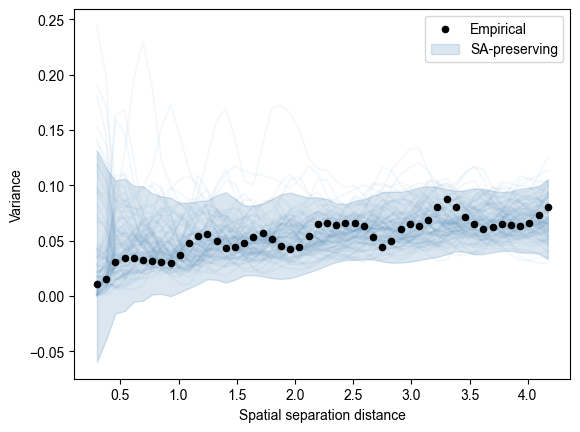

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction/brainsmash_correlation_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


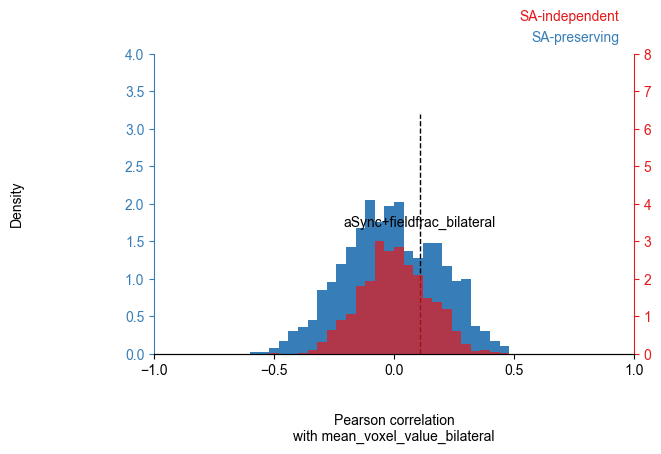

In [7]:
test_stat_dbm_f, p_value_naive_dbm_f, p_value_sa_dbm_f = brainsmash_correlation(tsv_file1=DBM_bilateral_tsv,
                                                                       tsv_file2=regional_fieldfraction_bilateral_tsv,
                                                                       col1="mean_voxel_value_bilateral",
                                                                       col2="aSync+fieldfrac_bilateral",
                                                                       output_dir=f"{working_dir}/correlations/DBM_fieldfraction",
                                                                       output_file_stem="DBM_fieldfraction_correlation",
                                                                       n_surrogates=no_surrogates,)

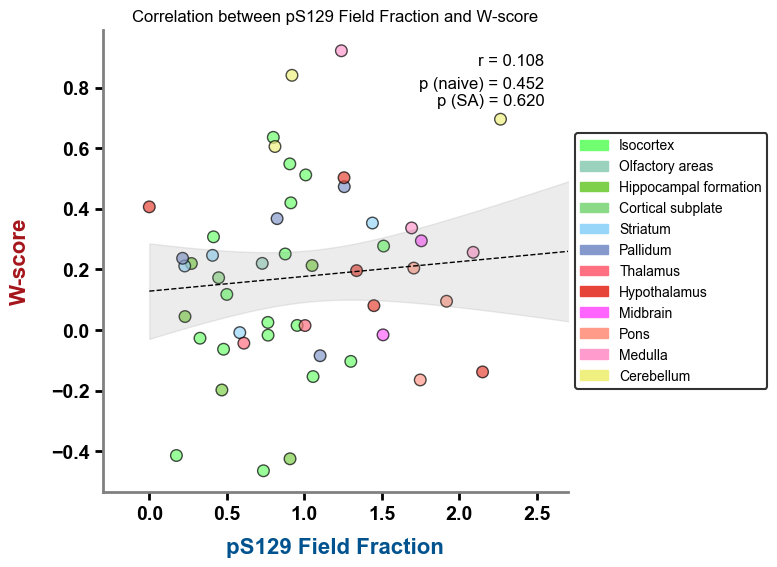

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction/DBM_fieldfraction_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(0.10777671156608719,
 <Axes: title={'center': 'Correlation between pS129 Field Fraction and W-score'}, xlabel='pS129 Field Fraction', ylabel='W-score'>)

In [8]:
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=DBM_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_fieldfraction",
                        output_file_stem="DBM_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_f,
                        brainsmash_naive_pval=p_value_naive_dbm_f,
                        brainsmash_sa_pval=p_value_sa_dbm_f,
                        xlim=xlim)

# <font color="#28cf33ff"> ================DBM_stephanie-fieldfraction correlation================

In [9]:
DBM_stephanie_bilateral_tsv = f"{working_dir}/metrics/DBM_stephanie/average_DBM_stephanie_bilateral.tsv"
regional_fieldfraction_bilateral_tsv = f"{working_dir}/metrics/fieldfraction/average_fieldfraction_bilateral.tsv"


Correlation coefficient: -0.3086888947457721
Spatially naive p-value: 0.029
SA-corrected p-value: 0.119
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction_stephanie/brainsmash_variogram_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


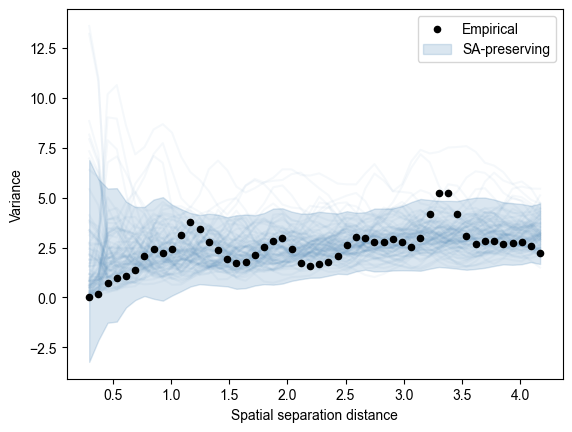

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction_stephanie/brainsmash_correlation_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


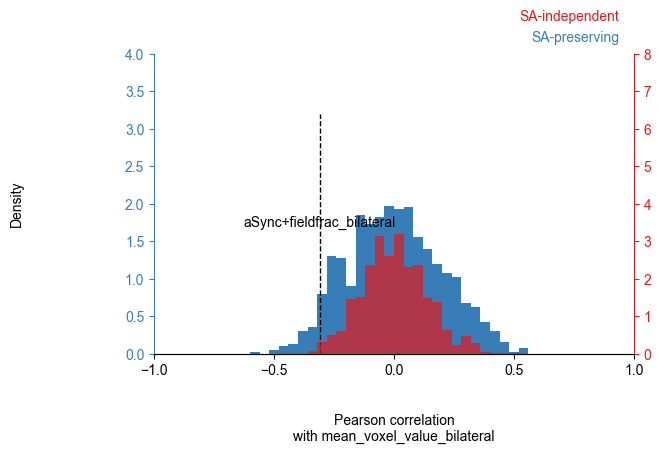

In [10]:
test_stat_dbm_stephanie_f, p_value_naive_dbm_stephanie_f, p_value_sa_dbm_stephanie_f = brainsmash_correlation(tsv_file1=DBM_stephanie_bilateral_tsv,
                                                                       tsv_file2=regional_fieldfraction_bilateral_tsv,
                                                                       col1="mean_voxel_value_bilateral",
                                                                       col2="aSync+fieldfrac_bilateral",
                                                                       output_dir=f"{working_dir}/correlations/DBM_fieldfraction_stephanie",
                                                                       output_file_stem="DBM_fieldfraction_stephanie_correlation",
                                                                       n_surrogates=no_surrogates,)

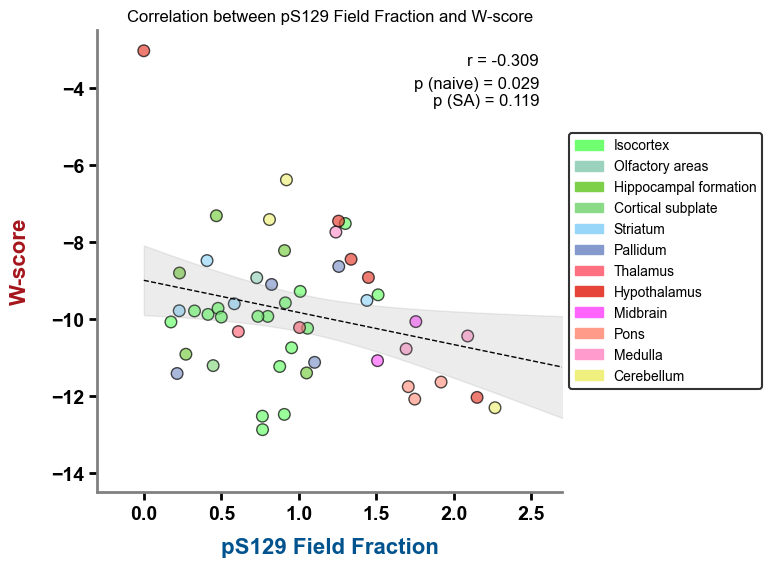

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction_stephanie/DBM_fieldfraction_stephanie_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.3086888947457721,
 <Axes: title={'center': 'Correlation between pS129 Field Fraction and W-score'}, xlabel='pS129 Field Fraction', ylabel='W-score'>)

In [11]:
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=DBM_stephanie_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_fieldfraction_stephanie",
                        output_file_stem="DBM_fieldfraction_stephanie_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_stephanie_f,
                        brainsmash_naive_pval=p_value_naive_dbm_stephanie_f,
                        brainsmash_sa_pval=p_value_sa_dbm_stephanie_f,
                        xlim=xlim)

# <font color="#28cf33ff"> ================DBM_stephanie_smoothed-fieldfraction correlation================

In [23]:
DBM_stephanie_smoothed_bilateral_tsv = f"{working_dir}/metrics/DBM_stephanie_smoothed/average_DBM_stephanie_smoothed_bilateral.tsv"
regional_fieldfraction_bilateral_tsv = f"{working_dir}/metrics/fieldfraction/average_fieldfraction_bilateral.tsv"


Correlation coefficient: -0.32305427508046247
Spatially naive p-value: 0.02
SA-corrected p-value: 0.122
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction_stephanie_smoothed/brainsmash_variogram_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


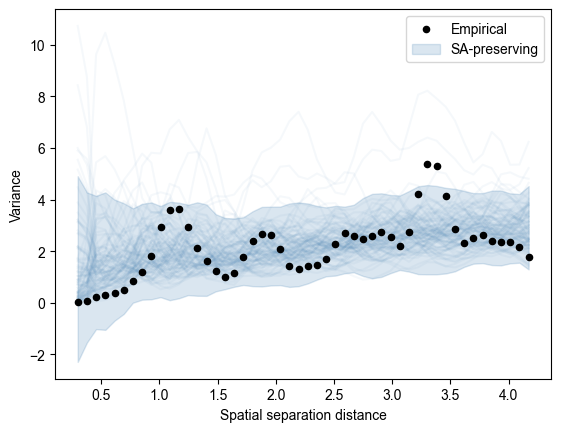

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction_stephanie_smoothed/brainsmash_correlation_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


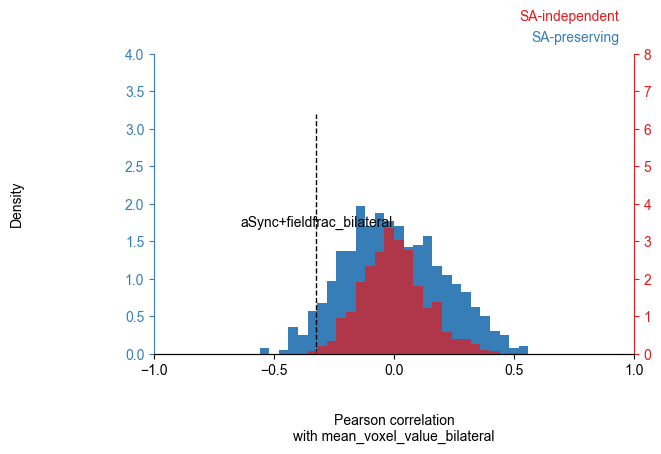

In [24]:
test_stat_dbm_stephanie_smoothed_f, p_value_naive_dbm_stephanie_smoothed_f, p_value_sa_dbm_stephanie_smoothed_f = brainsmash_correlation(tsv_file1=DBM_stephanie_smoothed_bilateral_tsv,
                                                                       tsv_file2=regional_fieldfraction_bilateral_tsv,
                                                                       col1="mean_voxel_value_bilateral",
                                                                       col2="aSync+fieldfrac_bilateral",
                                                                       output_dir=f"{working_dir}/correlations/DBM_fieldfraction_stephanie_smoothed",
                                                                       output_file_stem="DBM_fieldfraction_stephanie_smoothed_correlation",
                                                                       n_surrogates=no_surrogates,)

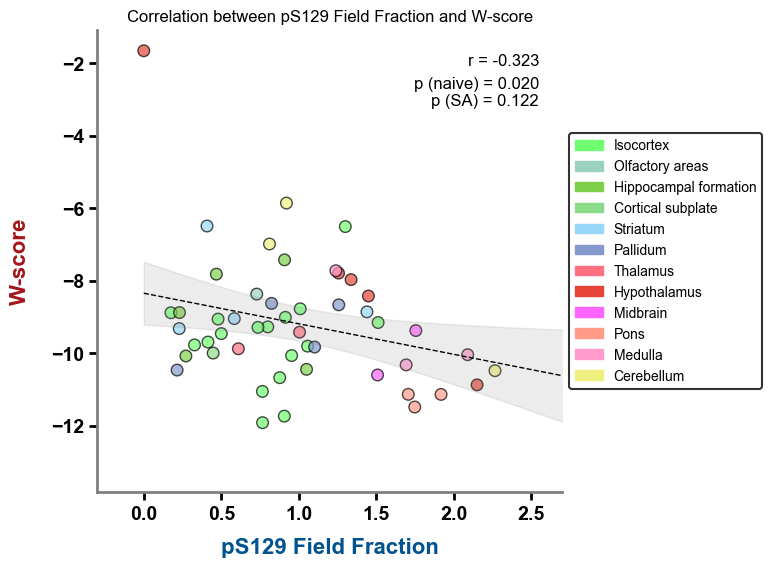

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_fieldfraction_stephanie_smoothed/DBM_fieldfraction_stephanie_smoothed_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.32305427508046247,
 <Axes: title={'center': 'Correlation between pS129 Field Fraction and W-score'}, xlabel='pS129 Field Fraction', ylabel='W-score'>)

In [25]:
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=DBM_stephanie_smoothed_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_fieldfraction_stephanie_smoothed",
                        output_file_stem="DBM_fieldfraction_stephanie_smoothed_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_stephanie_smoothed_f,
                        brainsmash_naive_pval=p_value_naive_dbm_stephanie_smoothed_f,
                        brainsmash_sa_pval=p_value_sa_dbm_stephanie_smoothed_f,
                        xlim=xlim,)

# <font color="#28cf33ff"> ================regional_TA-fieldfraction correlation================================

In [12]:
regional_TA_bilateral_tsv = f"{working_dir}/metrics/regional_TA/average_regional_TA_bilateral.tsv"
regional_fieldfraction_bilateral_tsv = f"{working_dir}/metrics/fieldfraction/average_fieldfraction_bilateral.tsv"



Correlation coefficient: -0.22708680082218027
Spatially naive p-value: 0.115
SA-corrected p-value: 0.242
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/regional_TA_fieldfraction/brainsmash_variogram_regional_TA_bilateral_aSync+fieldfrac_bilateral.svg


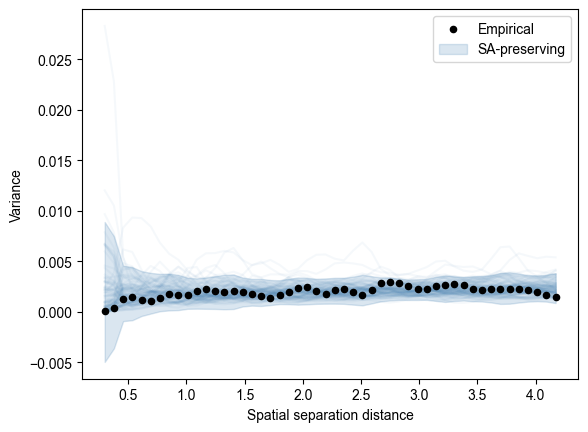

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/regional_TA_fieldfraction/brainsmash_correlation_regional_TA_bilateral_aSync+fieldfrac_bilateral.svg


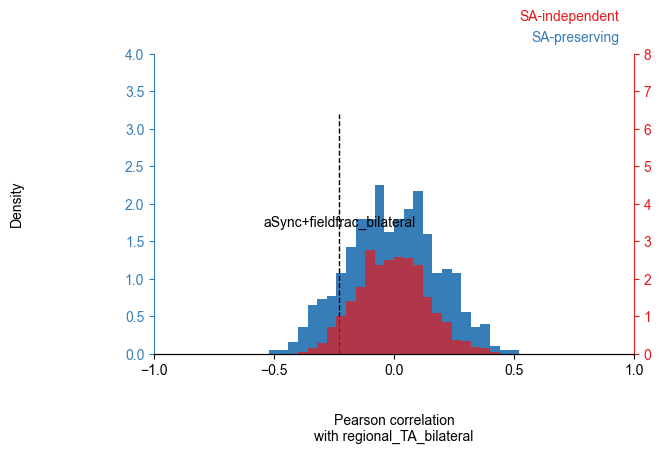

In [13]:
test_stat_TA_f, p_value_naive_TA_f, p_value_sa_TA_f = brainsmash_correlation(tsv_file1=regional_TA_bilateral_tsv,
                                                                       tsv_file2=regional_fieldfraction_bilateral_tsv,
                                                                       col1="regional_TA_bilateral",
                                                                       col2="aSync+fieldfrac_bilateral",
                                                                       output_dir=f"{working_dir}/correlations/regional_TA_fieldfraction",
                                                                       output_file_stem="regional_TA_fieldfraction_correlation",
                                                                       n_surrogates=no_surrogates,)




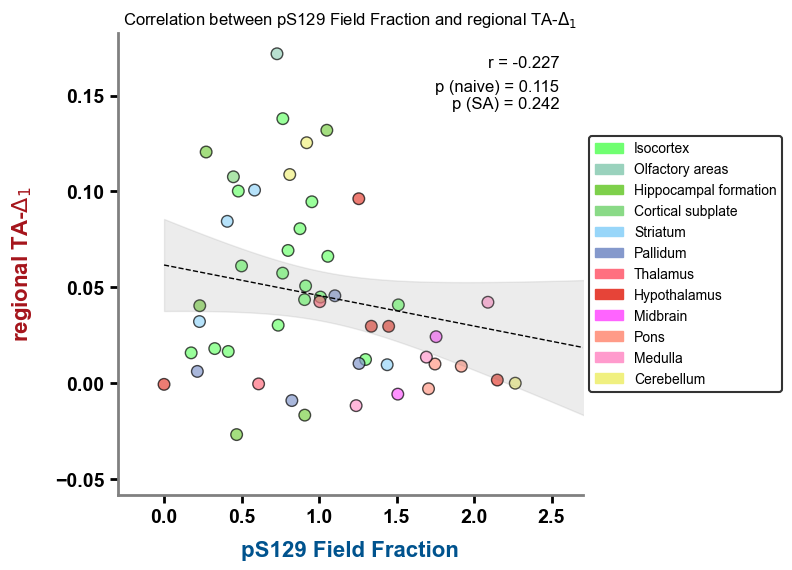

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/regional_TA_fieldfraction/regional_TA_fieldfraction_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.22708680082218027,
 <Axes: title={'center': 'Correlation between pS129 Field Fraction and regional TA-$\\Delta_1$'}, xlabel='pS129 Field Fraction', ylabel='regional TA-$\\Delta_1$'>)

In [14]:
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=regional_TA_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="regional_TA_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label=r"regional TA-$\Delta_1$",
                        output_dir=f"{working_dir}/correlations/regional_TA_fieldfraction",
                        output_file_stem="regional_TA_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_TA_f,
                        brainsmash_naive_pval=p_value_naive_TA_f,
                        brainsmash_sa_pval=p_value_sa_TA_f,
                      xlim=xlim)

# <font color="#28cf33ff"> ================seed conn-fieldfraction correlation================================

In [15]:
seed_FC_bilateral_tsv = f"{working_dir}/metrics/seed_FC/average_seed_FC_bilateral.tsv"
regional_fieldfraction_bilateral_tsv = f"{working_dir}/metrics/fieldfraction/average_fieldfraction_bilateral.tsv"



Correlation coefficient: -0.3644867431839515
Spatially naive p-value: 0.01
SA-corrected p-value: 0.043
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/seed_FC_fieldfraction/brainsmash_variogram_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


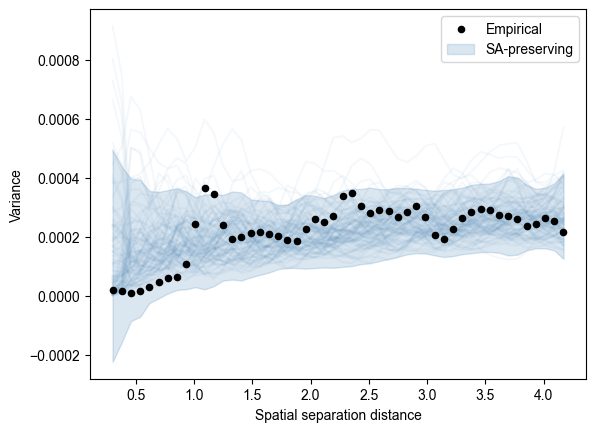

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/seed_FC_fieldfraction/brainsmash_correlation_mean_voxel_value_bilateral_aSync+fieldfrac_bilateral.svg


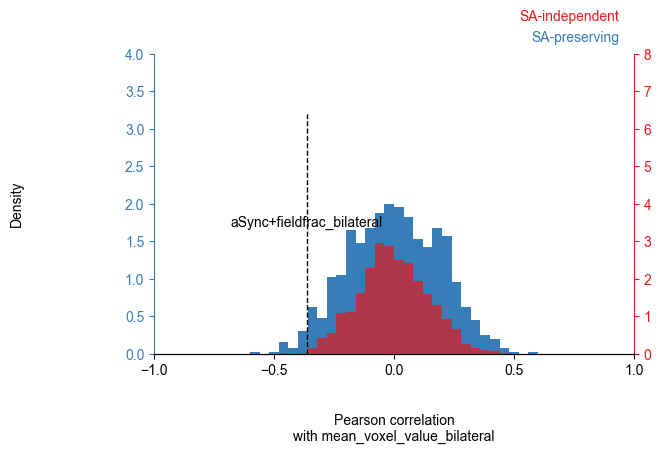

In [16]:
test_stat_seed_f, p_value_naive_seed_f, p_value_sa_seed_f = brainsmash_correlation(tsv_file1=seed_FC_bilateral_tsv,
                                                                       tsv_file2=regional_fieldfraction_bilateral_tsv,
                                                                       col1="mean_voxel_value_bilateral",
                                                                       col2="aSync+fieldfrac_bilateral",
                                                                       output_dir=f"{working_dir}/correlations/seed_FC_fieldfraction",
                                                                       output_file_stem="seed_FC_fieldfraction_correlation",
                                                                       n_surrogates=no_surrogates)

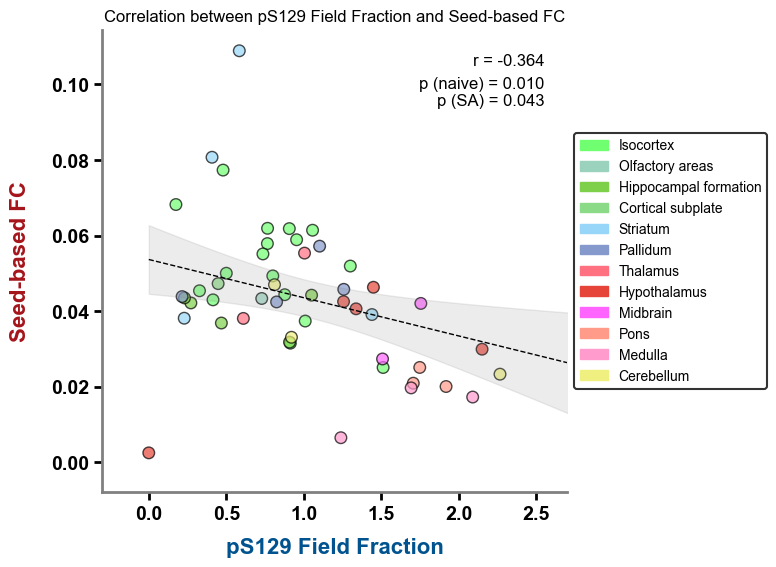

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/seed_FC_fieldfraction/seed_FC_fieldfraction_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.3644867431839515,
 <Axes: title={'center': 'Correlation between pS129 Field Fraction and Seed-based FC'}, xlabel='pS129 Field Fraction', ylabel='Seed-based FC'>)

In [17]:
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=seed_FC_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="Seed-based FC",
                        output_dir=f"{working_dir}/correlations/seed_FC_fieldfraction",
                        output_file_stem="seed_FC_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_seed_f,
                        brainsmash_naive_pval=p_value_naive_seed_f,
                        brainsmash_sa_pval=p_value_sa_seed_f,
                      xlim=xlim)

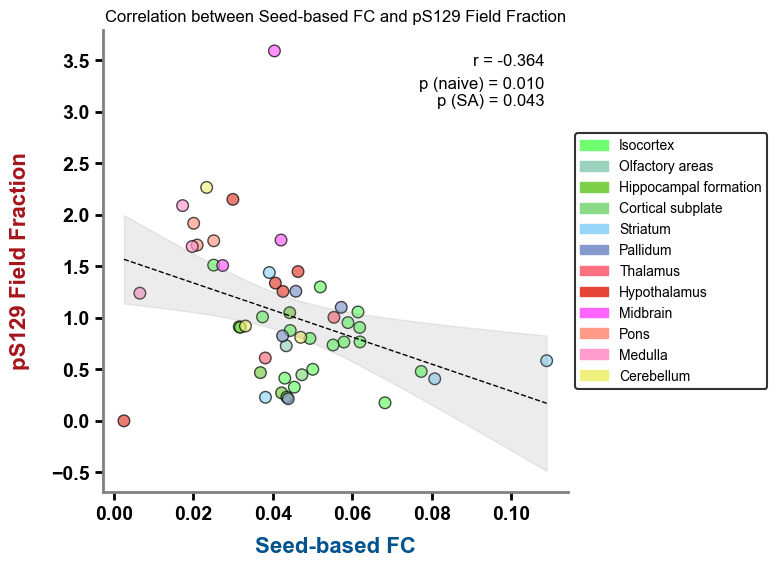

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/seed_FC_fieldfraction/seed_FC_fieldfraction_correlation_reverse.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.3644867431839515,
 <Axes: title={'center': 'Correlation between Seed-based FC and pS129 Field Fraction'}, xlabel='Seed-based FC', ylabel='pS129 Field Fraction'>)

In [18]:
correlate_tsv_columns(tsv_file2=regional_fieldfraction_bilateral_tsv,
                        tsv_file1=seed_FC_bilateral_tsv,
                        col2="aSync+fieldfrac_bilateral",
                        col1="mean_voxel_value_bilateral",
                        y_label="pS129 Field Fraction",
                        x_label="Seed-based FC",
                        output_dir=f"{working_dir}/correlations/seed_FC_fieldfraction",
                        output_file_stem="seed_FC_fieldfraction_correlation_reverse",
                        color_vector=None,
                        brainsmash_corr=test_stat_seed_f,
                        brainsmash_naive_pval=p_value_naive_seed_f,
                        brainsmash_sa_pval=p_value_sa_seed_f,)

# <font color="#28cf33ff"> ================Struc conn-fieldfrcation correlation================================

In [19]:
struc_conn_R_positive_tsv = f"{working_dir}/metrics/struc_conn/CP_avg_conn_right_positive_str_log10.tsv"
regional_fieldfraction_R_positive_tsv = f"{working_dir}/metrics/fieldfraction/average_fieldfraction_R_positive.tsv"


Correlation coefficient: 0.5271115650035347
Spatially naive p-value: 0.005
SA-corrected p-value: 0.007
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/struc_conn_fieldfraction/brainsmash_variogram_aSync+fieldfrac_connection_strength_log10.svg


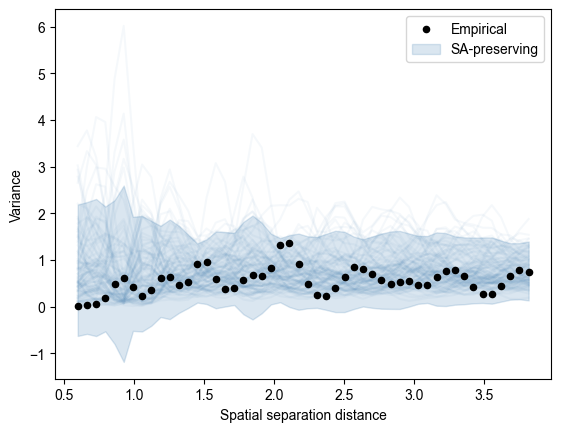

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/struc_conn_fieldfraction/brainsmash_correlation_aSync+fieldfrac_connection_strength_log10.svg


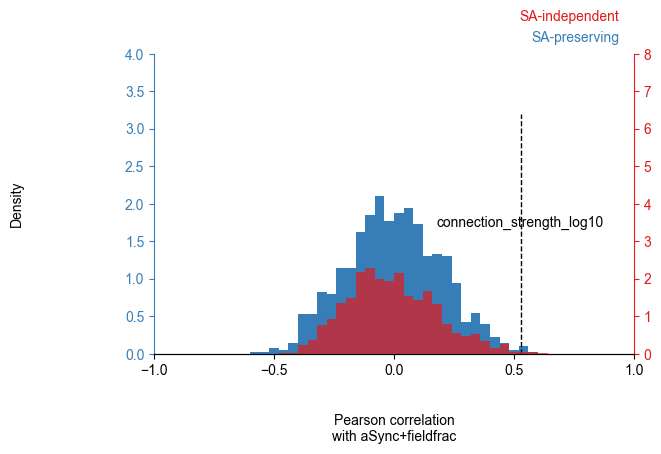

In [20]:
test_stat_stru_f, p_value_naive_stru_f, p_value_sa_stru_f = brainsmash_correlation(tsv_file2=struc_conn_R_positive_tsv,
                                                                       tsv_file1=regional_fieldfraction_R_positive_tsv,
                                                                       col2="connection_strength_log10",
                                                                       col1="aSync+fieldfrac",
                                                                       output_dir=f"{working_dir}/correlations/struc_conn_fieldfraction",
                                                                       output_file_stem="struc_conn_fieldfraction_correlation",
                                                                       n_surrogates=no_surrogates,
                                                                       atlas_labels=f"{working_dir}/metrics/struc_conn/positive_structures_labels.csv",
                                                                        )



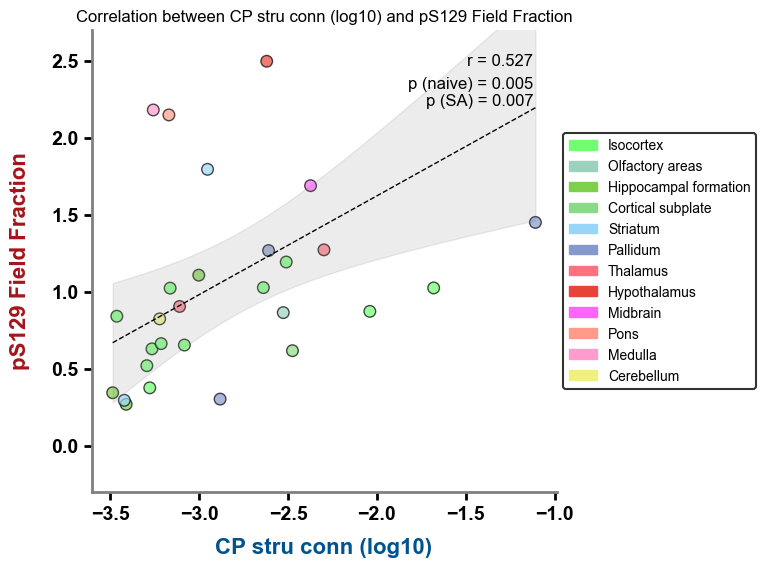

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/struc_conn_fieldfraction/struc_conn_fieldfraction_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(0.5271115650035347,
 <Axes: title={'center': 'Correlation between CP stru conn (log10) and pS129 Field Fraction'}, xlabel='CP stru conn (log10)', ylabel='pS129 Field Fraction'>)

In [21]:
correlate_tsv_columns(tsv_file2=regional_fieldfraction_R_positive_tsv,
                        tsv_file1=struc_conn_R_positive_tsv,
                        col2="aSync+fieldfrac",
                        col1="connection_strength_log10",
                        y_label="pS129 Field Fraction",
                        x_label="CP stru conn (log10)",
                        output_dir=f"{working_dir}/correlations/struc_conn_fieldfraction",
                        output_file_stem="struc_conn_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_stru_f,
                        brainsmash_naive_pval=p_value_naive_stru_f,
                        brainsmash_sa_pval=p_value_sa_stru_f,
                      ylim=xlim)

# <font color="#28cf33ff"> ================Struc conn-DBM correlation================================

In [22]:
regional_DBM_R_positive_tsv = f"{working_dir}/metrics/DBM/average_DBM_R_positive.tsv"
struc_conn_R_positive_tsv = f"{working_dir}/metrics/struc_conn/CP_avg_conn_right_positive_str_log10.tsv"


Correlation coefficient: -0.0052135422106583664
Spatially naive p-value: 0.975
SA-corrected p-value: 0.971
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn/brainsmash_variogram_mean_voxel_value_connection_strength_log10.svg


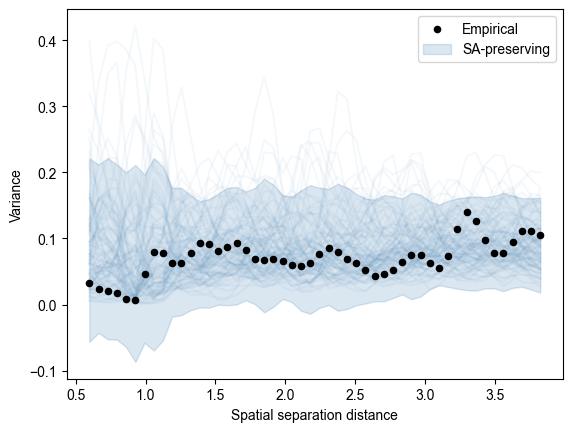

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn/brainsmash_correlation_mean_voxel_value_connection_strength_log10.svg


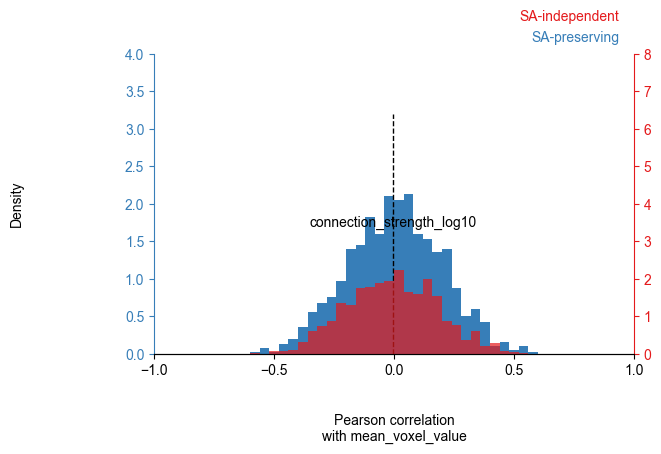

In [23]:
test_stat_dbm_struc_conn, p_value_naive_dbm_struc_conn, p_value_sa_dbm_struc_conn = brainsmash_correlation(tsv_file1=regional_DBM_R_positive_tsv,
                                                                       tsv_file2=struc_conn_R_positive_tsv,
                                                                       col1="mean_voxel_value",
                                                                       col2="connection_strength_log10",
                                                                       output_dir=f"{working_dir}/correlations/DBM_struc_conn",
                                                                       output_file_stem="DBM_struc_conn_correlation",
                                                                       n_surrogates=no_surrogates,
                                                                       atlas_labels=f"{working_dir}/metrics/struc_conn/positive_structures_labels.csv",
                                                                        )

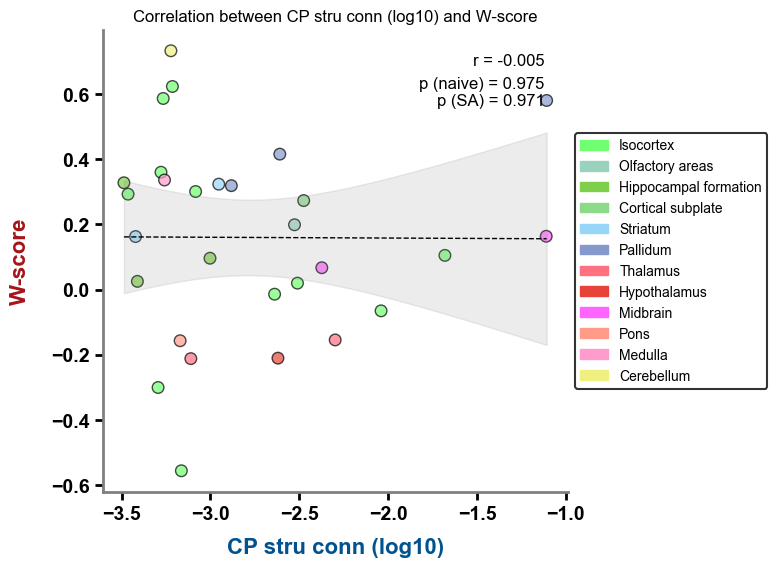

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn/DBM_struc_conn_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.0052135422106583664,
 <Axes: title={'center': 'Correlation between CP stru conn (log10) and W-score'}, xlabel='CP stru conn (log10)', ylabel='W-score'>)

In [24]:
correlate_tsv_columns(tsv_file1=struc_conn_R_positive_tsv,
                        tsv_file2=regional_DBM_R_positive_tsv,
                        col1="connection_strength_log10",
                        col2="mean_voxel_value",
                        x_label="CP stru conn (log10)",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_struc_conn",
                        output_file_stem="DBM_struc_conn_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_struc_conn,
                        brainsmash_naive_pval=p_value_naive_dbm_struc_conn,
                        brainsmash_sa_pval=p_value_sa_dbm_struc_conn,
)

# <font color="#28cf33ff"> ================Struc conn-DBM_stephanie correlation================================

In [25]:
regional_DBM_stephanie_R_positive_tsv = f"{working_dir}/metrics/DBM_stephanie/average_DBM_stephanie_R_positive.tsv"
struc_conn_R_positive_tsv = f"{working_dir}/metrics/struc_conn/CP_avg_conn_right_positive_str_log10.tsv"

Correlation coefficient: -0.12387113831508698
Spatially naive p-value: 0.536
SA-corrected p-value: 0.538
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn_stephanie/brainsmash_variogram_mean_voxel_value_connection_strength_log10.svg


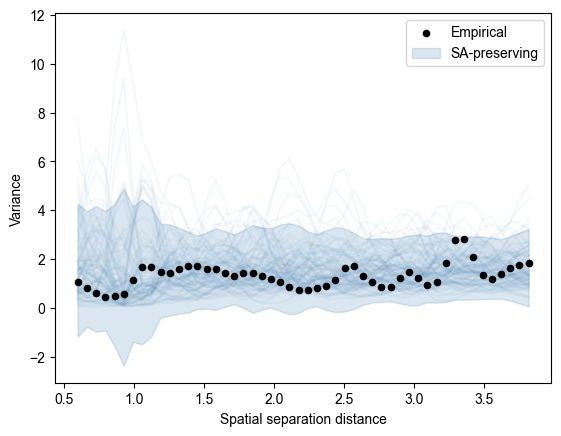

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn_stephanie/brainsmash_correlation_mean_voxel_value_connection_strength_log10.svg


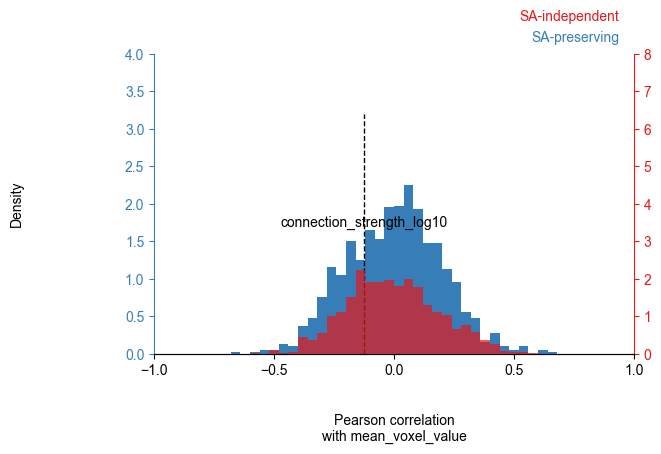

In [26]:
test_stat_dbm_stephanie_struc_conn, p_value_naive_dbm_stephanie_struc_conn, p_value_sa_dbm_stephanie_struc_conn = brainsmash_correlation(tsv_file1=regional_DBM_stephanie_R_positive_tsv,
                                                                       tsv_file2=struc_conn_R_positive_tsv,
                                                                       col1="mean_voxel_value",
                                                                       col2="connection_strength_log10",
                                                                       output_dir=f"{working_dir}/correlations/DBM_struc_conn_stephanie",
                                                                       output_file_stem="DBM_struc_conn_stephanie_correlation",
                                                                       n_surrogates=no_surrogates,
                                                                       atlas_labels=f"{working_dir}/metrics/struc_conn/positive_structures_labels.csv",
                                                                        )

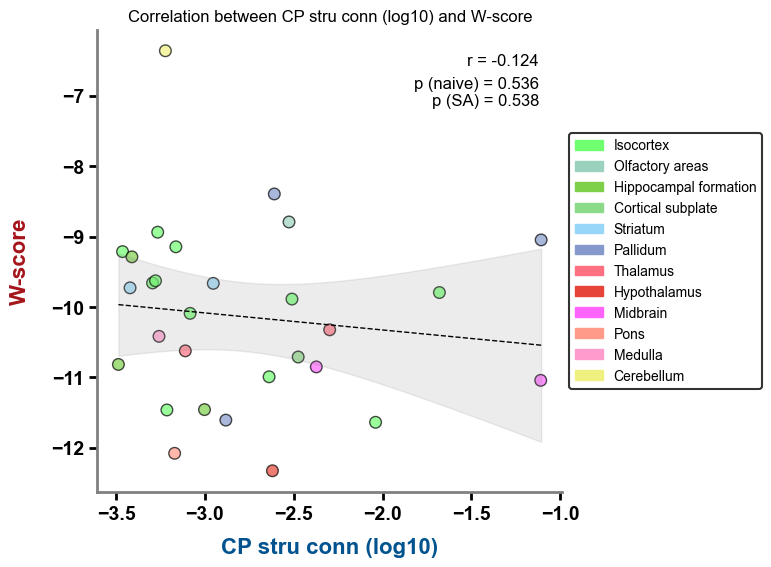

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn_stephanie/DBM_struc_conn_stephanie_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.12387113831508698,
 <Axes: title={'center': 'Correlation between CP stru conn (log10) and W-score'}, xlabel='CP stru conn (log10)', ylabel='W-score'>)

In [27]:

correlate_tsv_columns(tsv_file1=struc_conn_R_positive_tsv,
                        tsv_file2=regional_DBM_stephanie_R_positive_tsv,
                        col1="connection_strength_log10",
                        col2="mean_voxel_value",
                        x_label="CP stru conn (log10)",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_struc_conn_stephanie",
                        output_file_stem="DBM_struc_conn_stephanie_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_stephanie_struc_conn,
                        brainsmash_naive_pval=p_value_naive_dbm_stephanie_struc_conn,
                        brainsmash_sa_pval=p_value_sa_dbm_stephanie_struc_conn,
)

# <font color="#28cf33ff"> ================Struc conn-DBM_stephanie_smoothed correlation================================m

In [27]:
regional_DBM_stephanie_smoothed_R_positive_tsv = f"{working_dir}/metrics/DBM_stephanie_smoothed/average_DBM_stephanie_smoothed_R_positive.tsv"
struc_conn_R_positive_tsv = f"{working_dir}/metrics/struc_conn/CP_avg_conn_right_positive_str_log10.tsv"

Correlation coefficient: -0.12175499604820963
Spatially naive p-value: 0.525
SA-corrected p-value: 0.542
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn_stephanie_smoothed/brainsmash_variogram_mean_voxel_value_connection_strength_log10.svg


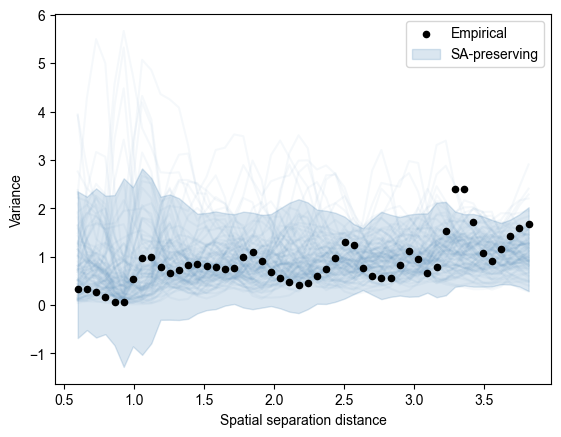

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn_stephanie_smoothed/brainsmash_correlation_mean_voxel_value_connection_strength_log10.svg


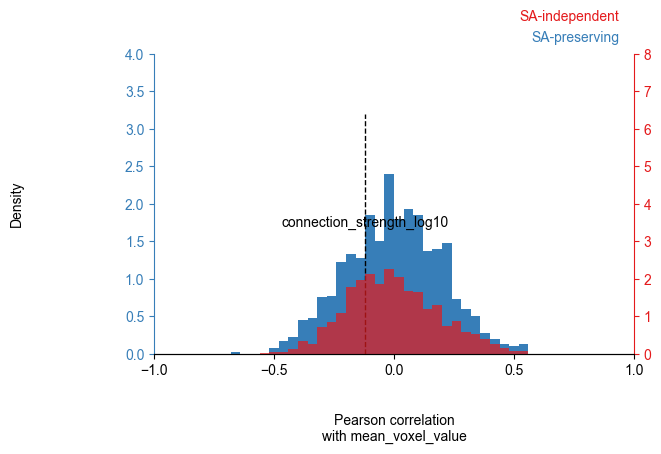

In [28]:
test_stat_dbm_stephanie_smoothed_struc_conn, p_value_naive_dbm_stephanie_smoothed_struc_conn, p_value_sa_dbm_stephanie_smoothed_struc_conn = brainsmash_correlation(tsv_file1=regional_DBM_stephanie_smoothed_R_positive_tsv,
                                                                       tsv_file2=struc_conn_R_positive_tsv,
                                                                       col1="mean_voxel_value",
                                                                       col2="connection_strength_log10",
                                                                       output_dir=f"{working_dir}/correlations/DBM_struc_conn_stephanie_smoothed",
                                                                       output_file_stem="DBM_struc_conn_stephanie_smoothed_correlation",
                                                                       n_surrogates=no_surrogates,
                                                                       atlas_labels=f"{working_dir}/metrics/struc_conn/positive_structures_labels.csv",
                                                                        )


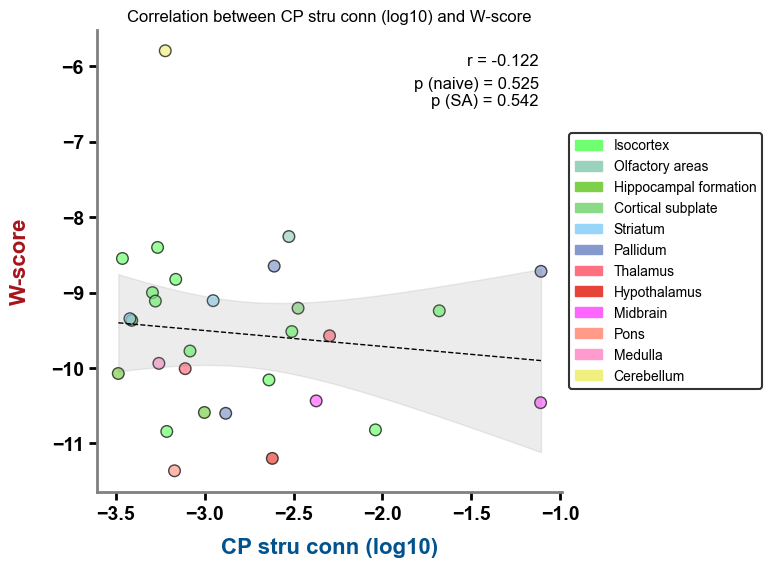

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/correlations/DBM_struc_conn_stephanie_smoothed/DBM_struc_conn_stephanie_smoothed_correlation.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


(-0.12175499604820963,
 <Axes: title={'center': 'Correlation between CP stru conn (log10) and W-score'}, xlabel='CP stru conn (log10)', ylabel='W-score'>)

In [29]:
correlate_tsv_columns(tsv_file1=struc_conn_R_positive_tsv,
                        tsv_file2=regional_DBM_stephanie_smoothed_R_positive_tsv,
                        col1="connection_strength_log10",
                        col2="mean_voxel_value",
                        x_label="CP stru conn (log10)",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_struc_conn_stephanie_smoothed",
                        output_file_stem="DBM_struc_conn_stephanie_smoothed_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_stephanie_smoothed_struc_conn,
                        brainsmash_naive_pval=p_value_naive_dbm_stephanie_smoothed_struc_conn,
                        brainsmash_sa_pval=p_value_sa_dbm_stephanie_smoothed_struc_conn,
)

# <font color="#28cf33ff"> ================combined plot================================

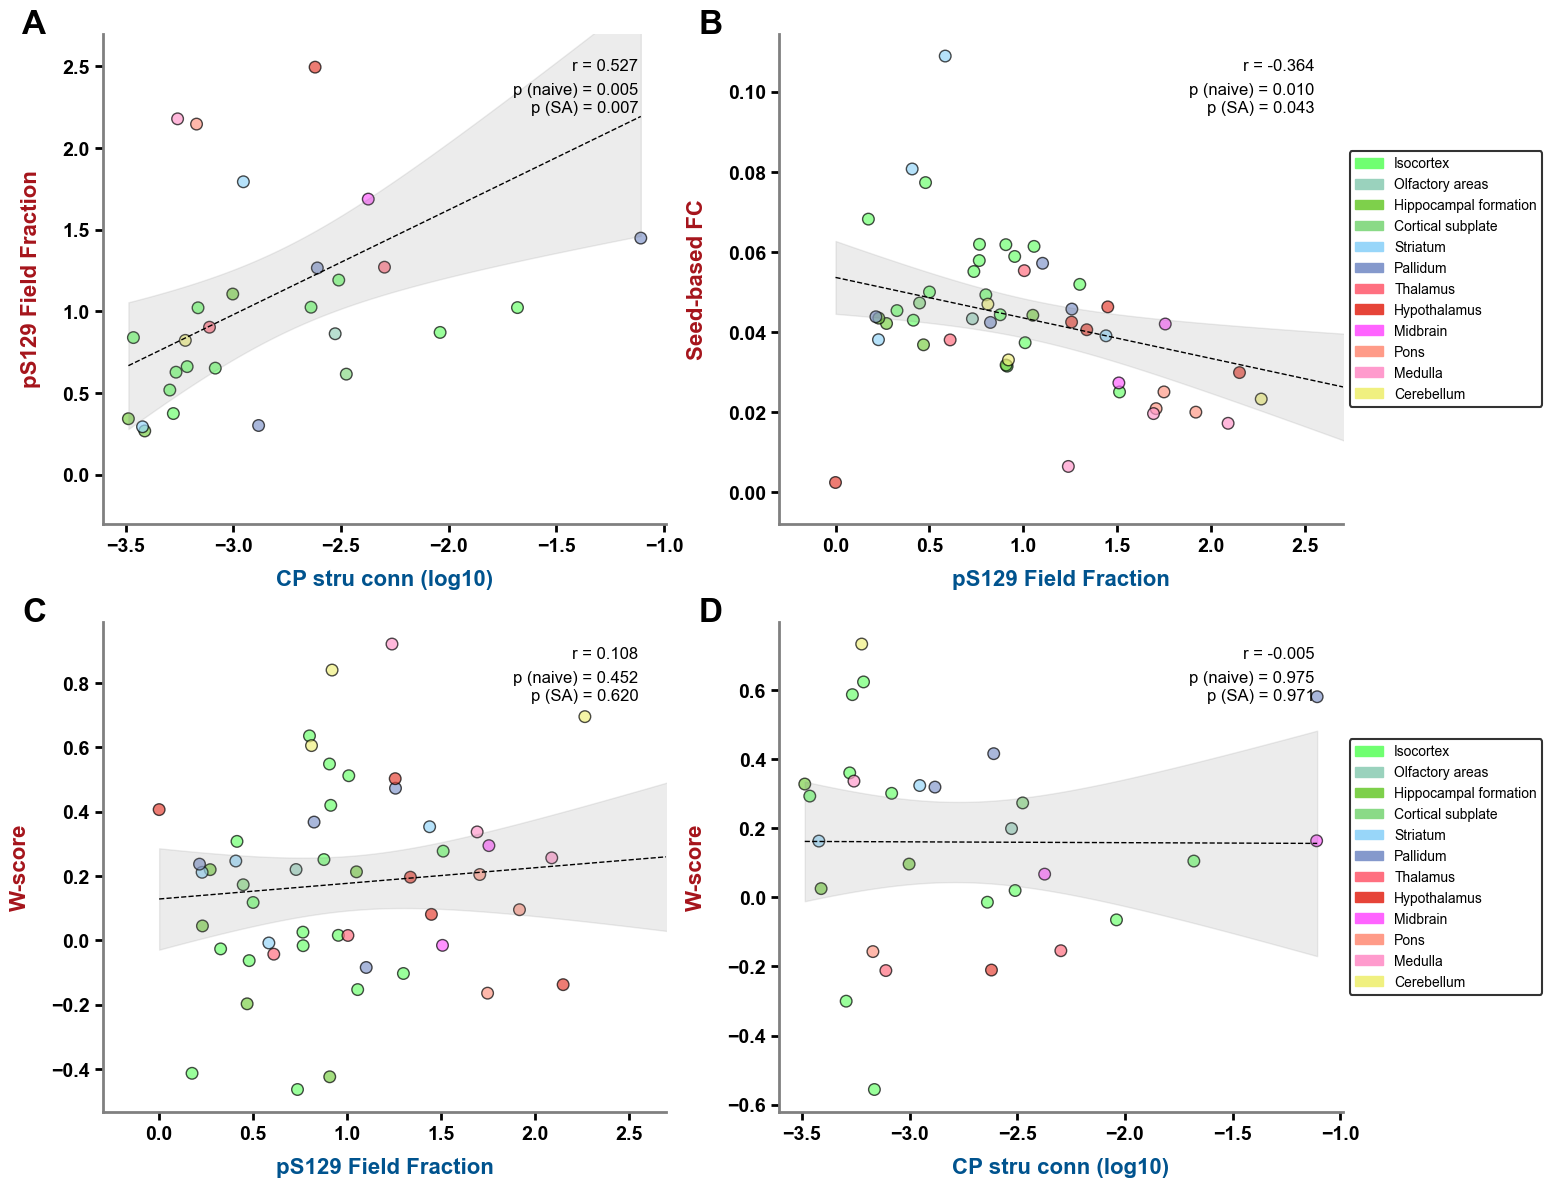

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
correlate_tsv_columns(tsv_file2=regional_fieldfraction_R_positive_tsv,
                        tsv_file1=struc_conn_R_positive_tsv,
                        col2="aSync+fieldfrac",
                        col1="connection_strength_log10",
                        y_label="pS129 Field Fraction",
                        x_label="CP stru conn (log10)",
                        output_dir=f"{working_dir}/correlations/struc_conn_fieldfraction",
                        output_file_stem="struc_conn_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_stru_f,
                        brainsmash_naive_pval=p_value_naive_stru_f,
                        brainsmash_sa_pval=p_value_sa_stru_f,
                      ylim=xlim,
                      ax=axes[0,0],
                      title=False,
                      legend=False)
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=seed_FC_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="Seed-based FC",
                        output_dir=f"{working_dir}/correlations/seed_FC_fieldfraction",
                        output_file_stem="seed_FC_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_seed_f,
                        brainsmash_naive_pval=p_value_naive_seed_f,
                        brainsmash_sa_pval=p_value_sa_seed_f,
                      xlim=xlim,
                      ax=axes[0,1],
                      title=False)
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=DBM_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_fieldfraction",
                        output_file_stem="DBM_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_f,
                        brainsmash_naive_pval=p_value_naive_dbm_f,
                        brainsmash_sa_pval=p_value_sa_dbm_f,
                        xlim=xlim, ax=axes[1,0],
                        title=False,
                      legend=False)
correlate_tsv_columns(tsv_file1=struc_conn_R_positive_tsv,
                        tsv_file2=regional_DBM_R_positive_tsv,
                        col1="connection_strength_log10",
                        col2="mean_voxel_value",
                        x_label="CP stru conn (log10)",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_struc_conn",
                        output_file_stem="DBM_struc_conn_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_struc_conn,
                        brainsmash_naive_pval=p_value_naive_dbm_struc_conn,
                        brainsmash_sa_pval=p_value_sa_dbm_struc_conn,
                        ax=axes[1,1],
                        title=False)

axes = axes.flatten()   # if axes is a 2D grid, e.g. from subplots(2, 2)

for ax, letter in zip(axes, "ABCD"):
    ax.text(-0.1, 1.05, letter, transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='right')

fig.savefig(f"{working_dir}/gorup_correlations.svg", bbox_inches="tight")
fig.savefig(f"{working_dir}/gorup_correlations.pdf", bbox_inches="tight")
fig.savefig(f"{working_dir}/gorup_correlations.png", bbox_inches="tight")
plt.show()

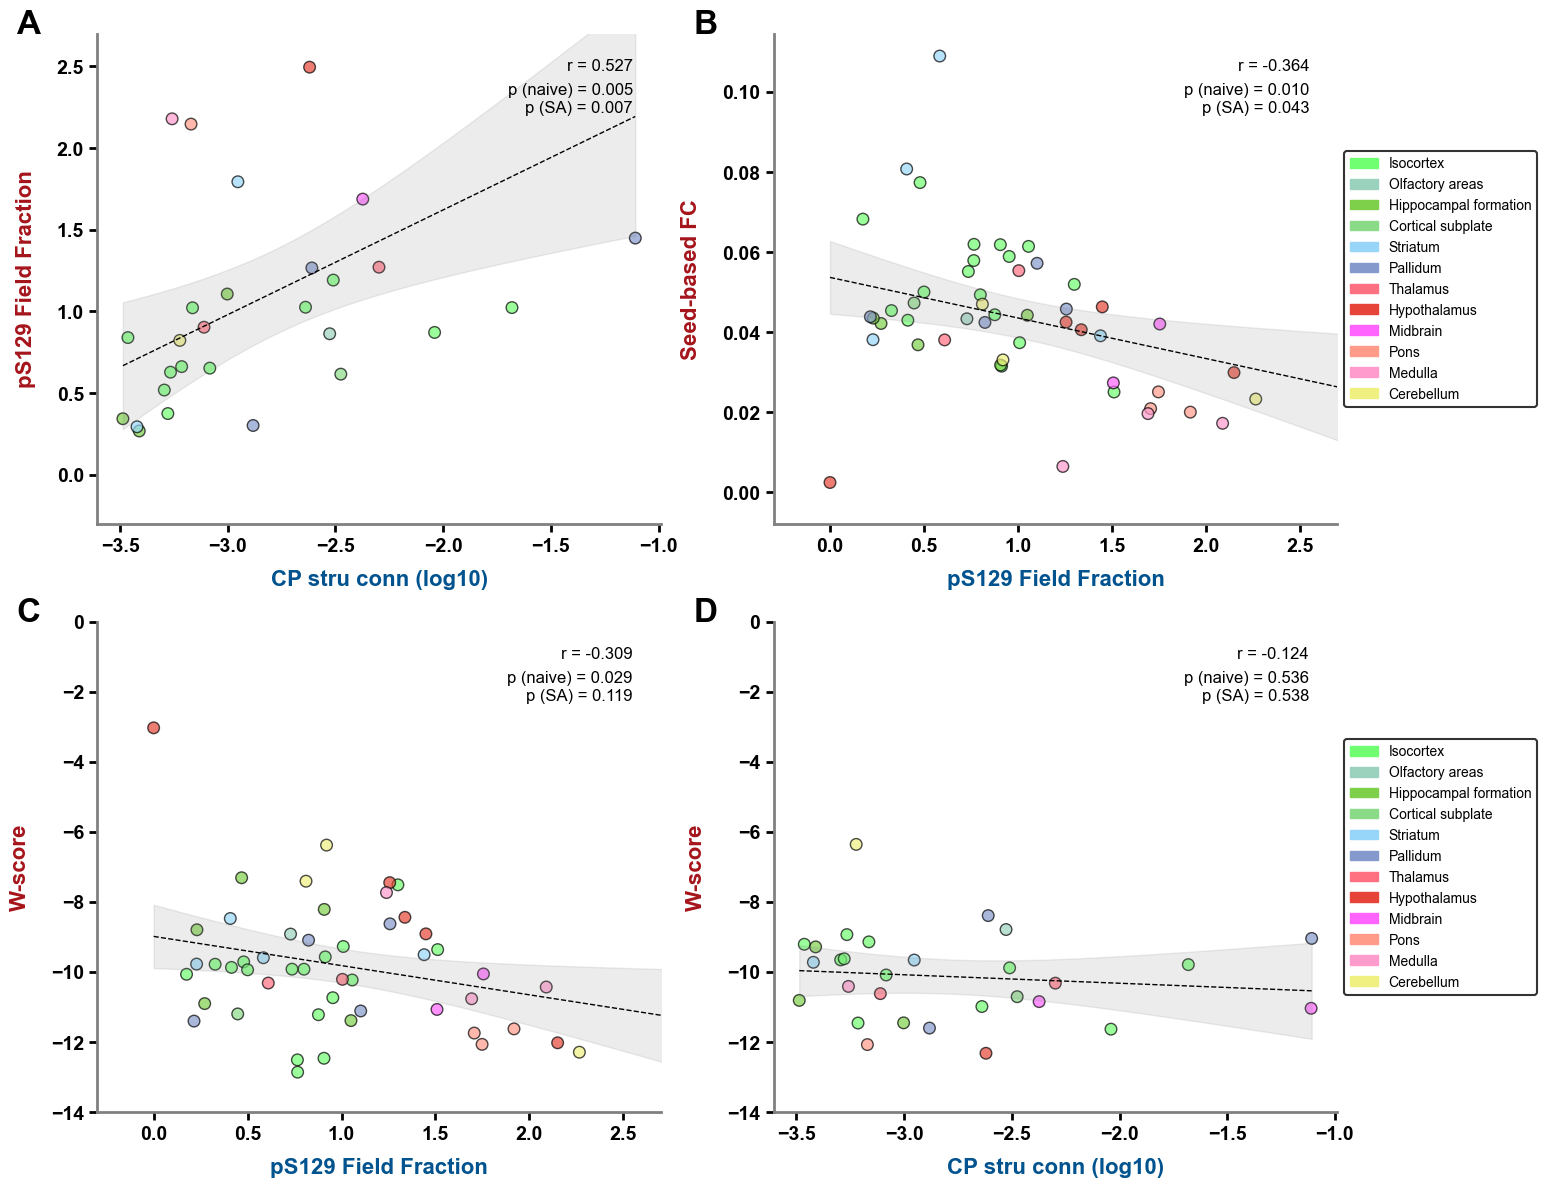

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
correlate_tsv_columns(tsv_file2=regional_fieldfraction_R_positive_tsv,
                        tsv_file1=struc_conn_R_positive_tsv,
                        col2="aSync+fieldfrac",
                        col1="connection_strength_log10",
                        y_label="pS129 Field Fraction",
                        x_label="CP stru conn (log10)",
                        output_dir=f"{working_dir}/correlations/struc_conn_fieldfraction",
                        output_file_stem="struc_conn_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_stru_f,
                        brainsmash_naive_pval=p_value_naive_stru_f,
                        brainsmash_sa_pval=p_value_sa_stru_f,
                      ylim=xlim,
                      ax=axes[0,0],
                      title=False,
                      legend=False)
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=seed_FC_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="Seed-based FC",
                        output_dir=f"{working_dir}/correlations/seed_FC_fieldfraction",
                        output_file_stem="seed_FC_fieldfraction_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_seed_f,
                        brainsmash_naive_pval=p_value_naive_seed_f,
                        brainsmash_sa_pval=p_value_sa_seed_f,
                      xlim=xlim,
                      ax=axes[0,1],
                      title=False)
correlate_tsv_columns(tsv_file1=regional_fieldfraction_bilateral_tsv,
                        tsv_file2=DBM_stephanie_bilateral_tsv,
                        col1="aSync+fieldfrac_bilateral",
                        col2="mean_voxel_value_bilateral",
                        x_label="pS129 Field Fraction",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_fieldfraction_stephanie",
                        output_file_stem="DBM_fieldfraction_stephanie_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_stephanie_f,
                        brainsmash_naive_pval=p_value_naive_dbm_stephanie_f,
                        brainsmash_sa_pval=p_value_sa_dbm_stephanie_f,
                        xlim=xlim, ax=axes[1,0],
                        title=False,
                      legend=False,
                      ylim=[-14, 0])
correlate_tsv_columns(tsv_file1=struc_conn_R_positive_tsv,
                        tsv_file2=regional_DBM_stephanie_R_positive_tsv,
                        col1="connection_strength_log10",
                        col2="mean_voxel_value",
                        x_label="CP stru conn (log10)",
                        y_label="W-score",
                        output_dir=f"{working_dir}/correlations/DBM_struc_conn_stephanie",
                        output_file_stem="DBM_struc_conn_stephanie_correlation",
                        color_vector=None,
                        brainsmash_corr=test_stat_dbm_stephanie_struc_conn,
                        brainsmash_naive_pval=p_value_naive_dbm_stephanie_struc_conn,
                        brainsmash_sa_pval=p_value_sa_dbm_stephanie_struc_conn,
                        ax=axes[1,1],
                        title=False,
                      ylim=[-14, 0],)

axes = axes.flatten()   # if axes is a 2D grid, e.g. from subplots(2, 2)

for ax, letter in zip(axes, "ABCD"):
    ax.text(-0.1, 1.05, letter, transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='right')

fig.savefig(f"{working_dir}/gorup_correlations_stephanie.svg", bbox_inches="tight")
fig.savefig(f"{working_dir}/gorup_correlations_stephanie.pdf", bbox_inches="tight")
fig.savefig(f"{working_dir}/gorup_correlations_stephanie.png", bbox_inches="tight")
plt.show()